In [1]:
import pandas as pd
import numpy as np
from skimpy import clean_columns
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import date
from datetime import datetime
import scipy.stats as stats
from datetime import timedelta

/Users/chloecho/anaconda3/envs/cornell_dev/lib/python3.11/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [34]:
deli_cup_25 = pd.read_csv('../2025/Data/deli_cup.csv')
deli_cup_25

,Container Number,Container Type,Project,Field ID,Treatment,Collection Date,Seed Type,Number Seeds,SCM Larvae Sum,SCM Pupae Sum,SCM Seed,Phorid Seed,Other Damage,Wireworms,Other Seeds,Wireworm Presence/absence,Grub presence/absence,Checked?,Ordered Entered,Notes
0,25_D_1181,DELI,R,CER_DEL_1,NEONIC,5/28/25,FIELD CORN,14.0,1,0,0,0,1,3,0,YES,YES,Y,294,NaN
1,25_D_1182,DELI,R,CER_DEL_1,FUNG,5/28/25,FIELD CORN,14.0,0,0,0,0,0,0,0,NO,NO,Y,293,NaN
2,25_D_1183,DELI,R,CER_DEL_1,NEONIC,5/28/25,FIELD CORN,17.0,2,0,0,0,0,0,0,NO,NO,Y,380,NaN
3,25_D_1184,DELI,R,CER_DEL_1,NEONIC,5/28/25,FIELD CORN,15.0,0,0,0,0,0,0,0,NO,NO,Y,308,NaN
4,25_D_1185,DELI,R,CER_DEL_1,FUNG,5/28/25,FIELD CORN,15.0,2,0,0,0,0,0,0,NO,NO,Y,51,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
981,25_D_2513,DELI,R,ZUE_VOT,FUNG,7/4/25,SNAP,15.0,0,0,0,0,0,0,0,NO,NO,Y,712,NaN
982,25_D_2514,DELI,R,ZUE_VOT,FUNG,7/3/25,SNAP,15.0,0,0,0,0,0,0,0,NO,NO,Y,710,NaN
983,25_D_2515,DELI,R,ZUE_VOT,FUNG,7/8/25,SNAP,15.0,0,0,0,0,0,0,0,NO,NO,Y,716,NaN
984,25_D_2516,DELI,R,ZUE_VOT,FUNG,7/6/25,SNAP,15.0,0,0,0,0,0,0,0,NO,NO,Y,714,NaN


In [35]:
deli_cup_26 = pd.read_csv('Data/deli_cup.csv')
deli_cup_26

,Sample ID,"Project (R, L, C)",Field ID,Treatment,Collection Date,Seed Type,Number Seeds,SCM Larvae Sum,SCM Pupae Sum,SCM Seed,Phorid Seed,Other Damage,Wireworms,Other Seeds,Wireworm Presence/absence,Grub presence/absence,Checked?,Ordered Entered,Notes
0,26_D_1434,R,CHO_GEN,F,5/28/26,Field Corn,15,0,0,0,0,0,0.0,0,No,No,Yes,181,NaN
1,26_D_1433,R,CHO_GEN,F,5/28/26,Field Corn,15,2,0,0,0,0,0.0,0,No,No,Yes,185,NaN
2,26_D_1432,R,CHO_GEN,F,5/28/26,Field Corn,15,0,0,0,0,0,0.0,0,No,No,Yes,186,NaN
3,26_D_1426,R,CHO_GEN,F,5/28/26,Field Corn,15,0,0,0,0,2,0.0,2,No,No,Yes,205,NaN
4,26_D_1430,R,CHO_GEN,F,5/28/26,Field Corn,15,0,0,0,0,0,0.0,0,No,No,Yes,343,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
462,26_D_1135,R,STA_YUN,N,5/11/26,Soy,16,0,0,0,0,3,0.0,3,No,No,Yes,412,NaN
463,26_D_1138,R,STA_YUN,N,5/11/26,Soy,15,0,0,0,0,3,0.0,3,No,No,Yes,54,NaN
464,26_D_1140,R,STA_YUN,N,5/11/26,Soy,15,0,0,0,0,4,0.0,4,No,No,Yes,55,NaN
465,26_D_1139,R,STA_YUN,N,5/11/26,Soy,15,0,0,0,0,0,0.0,0,No,No,Yes,56,NaN


In [36]:
deli_cup_25['Total SCM'] = deli_cup_25['SCM Larvae Sum'] + deli_cup_25['SCM Pupae Sum']
deli_cup_26['Total SCM'] = deli_cup_26['SCM Larvae Sum'] + deli_cup_26['SCM Pupae Sum']

deli_cup_25 = deli_cup_25[(deli_cup_25['Seed Type'] != 'SWEET CORN') & (deli_cup_25['Seed Type'] != 'SNAP')]
deli_cup_26 = deli_cup_26[(deli_cup_26['Seed Type'] != 'Sweet Corn') & (deli_cup_26['Seed Type'] != 'Snap')]

deli_cup_25['Treatment'] = deli_cup_25['Treatment'].replace({'NEONIC': 'Neonicotinoid', 'FUNG': 'Fungicide'})
deli_cup_25['Seed Type'] = deli_cup_25['Seed Type'].replace({'FIELD CORN': 'Field corn', 'SOY': 'Soybean'})
deli_cup_25 = deli_cup_25.rename(columns={'Seed Type': 'Crop'})

deli_cup_26['Treatment'] = deli_cup_26['Treatment'].replace({'N': 'Neonicotinoid', 'F': 'Fungicide'})
deli_cup_26['Seed Type'] = deli_cup_26['Seed Type'].replace({'Soy': 'Soybean'})
deli_cup_26 = deli_cup_26.rename(columns={'Seed Type': 'Crop'})

deli_cup_25['Avg SCM'] = deli_cup_25['Total SCM'] / deli_cup_25['Number Seeds']
deli_cup_26['Avg SCM'] = deli_cup_26['Total SCM'] / deli_cup_26['Number Seeds']

/var/folders/vt/gz9c8wh17772k93xq1vtnl0c0000gn/T/ipykernel_6380/2458259314.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  deli_cup_25['Treatment'] = deli_cup_25['Treatment'].replace({'NEONIC': 'Neonicotinoid', 'FUNG': 'Fungicide'})
/var/folders/vt/gz9c8wh17772k93xq1vtnl0c0000gn/T/ipykernel_6380/2458259314.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  deli_cup_25['Seed Type'] = deli_cup_25['Seed Type'].replace({'FIELD CORN': 'Field corn', 'SOY': 'Soybean'})


(0.0, 1.0)

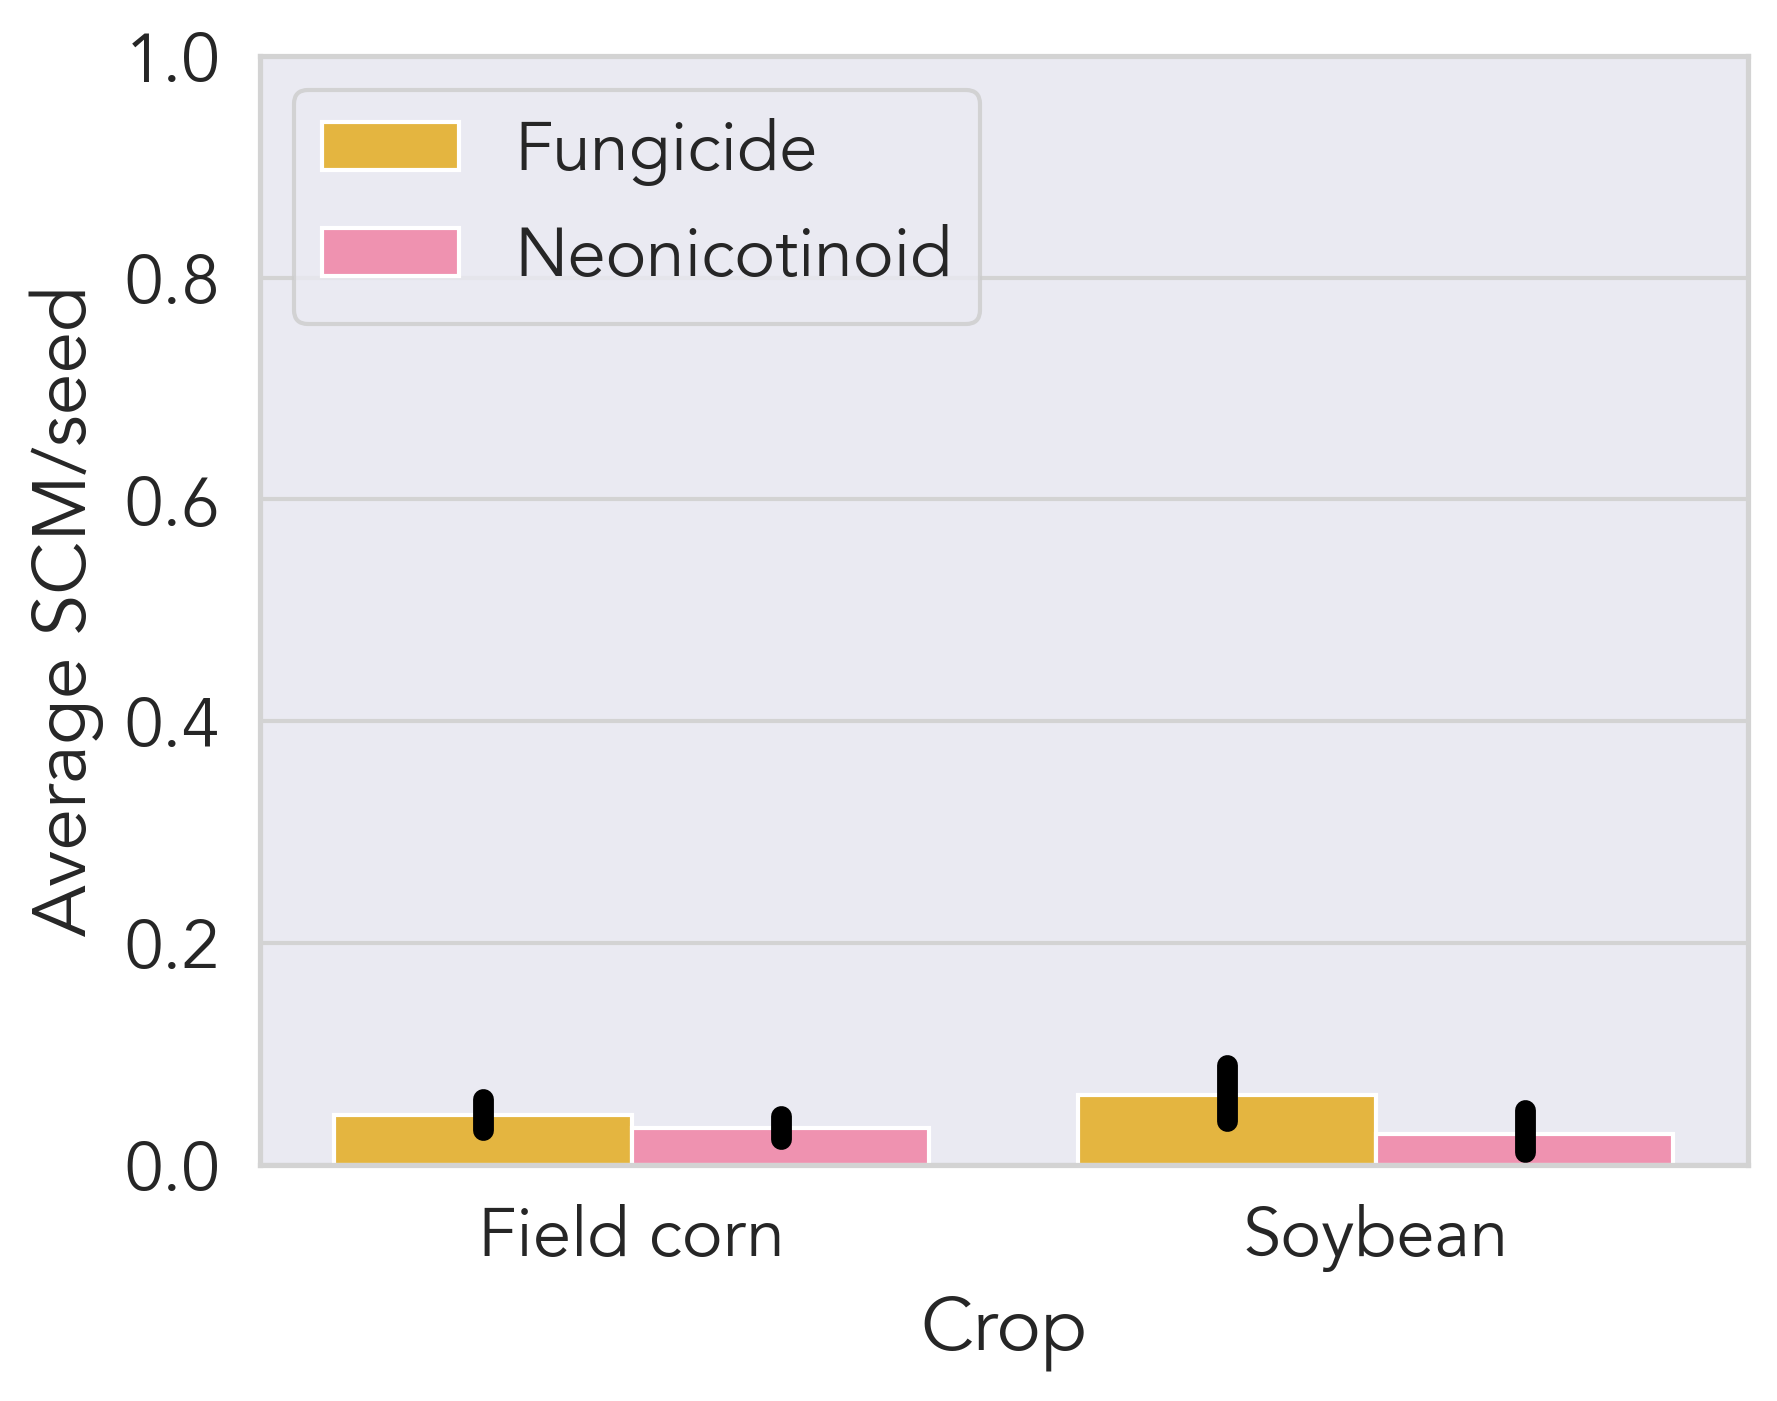

In [37]:
plt.figure()
plt.rcParams.update({"figure.dpi": 300})
sns.set(font="Avenir", font_scale=1.5, rc={'grid.color': 'lightgray', 'axes.edgecolor': 'lightgray', 'legend.frameon':True})

# palette = ['#7e3412', '#d2e1c1']
palette = ['#FFC125', '#FF82AB']
hue_order = ['Fungicide', 'Neonicotinoid']
ax = sns.barplot(data = deli_cup_25, x = 'Crop', y = 'Avg SCM', hue = 'Treatment', palette=palette, hue_order=hue_order, err_kws={'linewidth': 5, 'color':'black'})
plt.ylabel('Average SCM/seed')
plt.legend(loc='upper left')
plt.ylim(0, 1)


(0.0, 1.0)

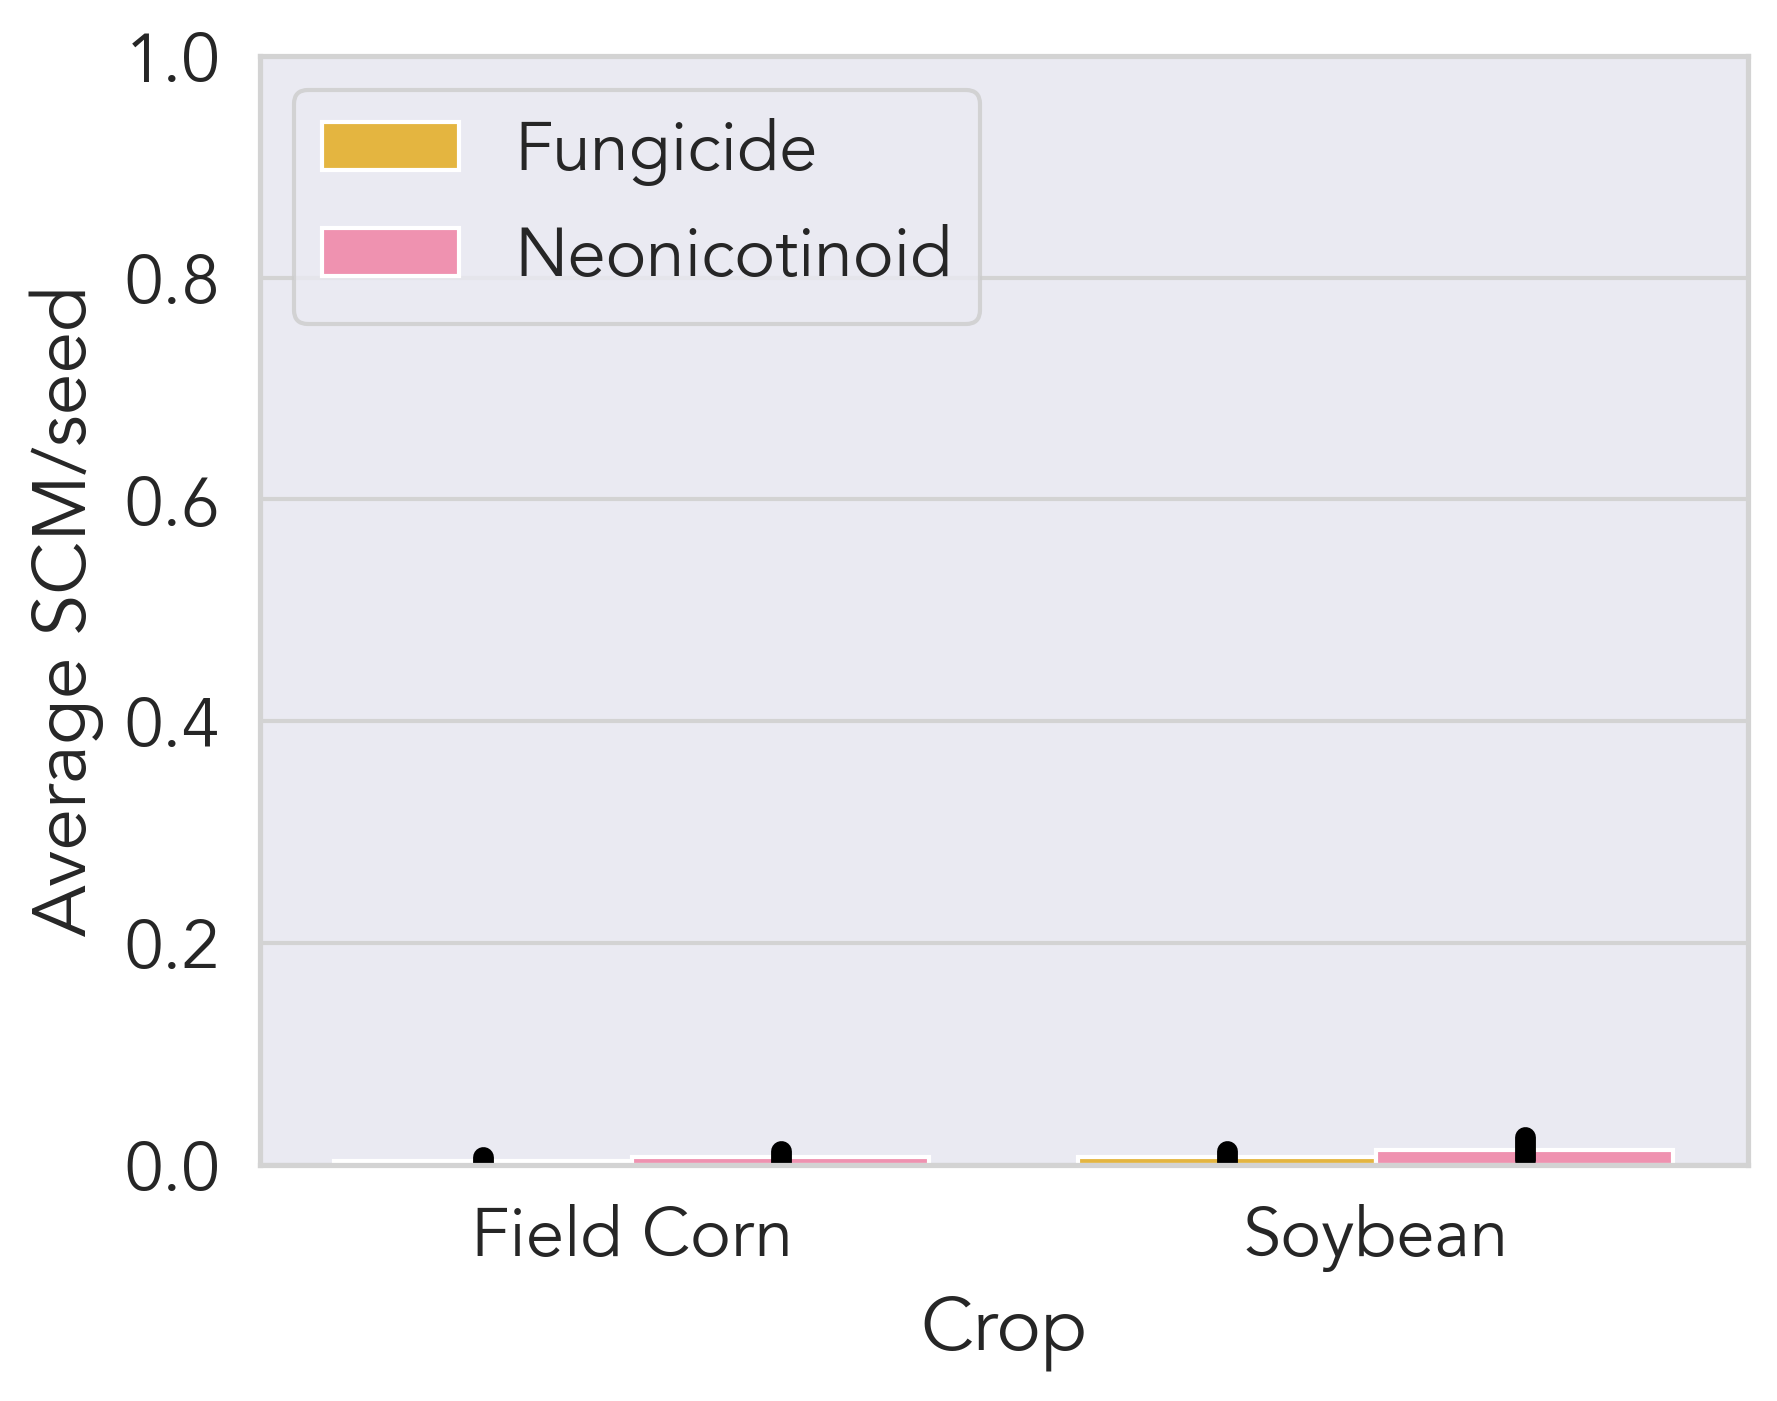

In [38]:
plt.figure()
plt.rcParams.update({"figure.dpi": 300})
sns.set(font="Avenir", font_scale=1.5, rc={'grid.color': 'lightgray', 'axes.edgecolor': 'lightgray', 'legend.frameon':True})

# palette = ['#7e3412', '#d2e1c1']
palette = ['#FFC125', '#FF82AB']
hue_order = ['Fungicide', 'Neonicotinoid']
ax = sns.barplot(data = deli_cup_26, x = 'Crop', y = 'Avg SCM', hue = 'Treatment', palette=palette, hue_order=hue_order, err_kws={'linewidth': 5, 'color':'black'})
plt.ylabel('Average SCM/seed')
plt.legend(loc='upper left')
plt.ylim(0, 1)


In [39]:
len(deli_cup_26['Field ID'].unique())

25

In [40]:
crop_dict = pd.Series(deli_cup_26.Crop.values, index = deli_cup_26['Field ID']).to_dict()
crop_dict

{'CHO_GEN': 'Field Corn',
 'DEG_VIL': 'Field Corn',
 'DOE_ZIE': 'Field Corn',
 'KUH_COL': 'Field Corn',
 'LET_VER': 'Field Corn',
 'LET_WAT': 'Field Corn',
 'SMI_ARN_1': 'Soybean',
 'SMI_ARN_2': 'Field Corn',
 'SMI_ARN_3': 'Field Corn',
 'SMI_BUR': 'Field Corn',
 'SMI_BUR_2': 'Field Corn',
 'SMI_COB': 'Field Corn',
 'SMI_CON_2': 'Field Corn',
 'SMI_DOU': 'Soybean',
 'SMI_HOF_2': 'Soybean',
 'SMI_MCC': 'Soybean',
 'STA_AUS': 'Soybean',
 'STA_FRE': 'Field Corn',
 'STA_MAR': 'Field Corn',
 'STA_REE_2': 'Field Corn',
 'STA_REE_3': 'Soybean',
 'STA_STA': 'Soybean',
 'STA_WIL': 'Soybean',
 'STA_WOO': 'Soybean',
 'STA_YUN': 'Soybean'}

In [41]:
t1 = deli_cup_26.loc[(deli_cup_26['Treatment'] == 'Neonicotinoid') & (deli_cup_26['Crop'] == 'Field Corn')].groupby('Field ID')['Avg SCM'].mean()
t2 = deli_cup_26.loc[(deli_cup_26['Treatment'] == 'Fungicide') & (deli_cup_26['Crop'] == 'Field Corn')].groupby('Field ID')['Avg SCM'].mean()
stats.ttest_rel(t1, t2)

TtestResult(statistic=0.6312112439930935, pvalue=0.5380721981665186, df=14)

In [42]:
t1 = deli_cup_26.loc[(deli_cup_26['Treatment'] == 'Neonicotinoid') & (deli_cup_26['Crop'] == 'Soybean')].groupby('Field ID')['Avg SCM'].mean()
t2 = deli_cup_26.loc[(deli_cup_26['Treatment'] == 'Fungicide') & (deli_cup_26['Crop'] == 'Soybean')].groupby('Field ID')['Avg SCM'].mean()
stats.ttest_rel(t1, t2)

TtestResult(statistic=0.5824390576329592, pvalue=0.5745704319634477, df=9)